In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import json


from src.config import OUT_PATH, PROJECT_PATH
from src.setting import ExcludSubj, get_data_grp, GetInfo

tfr_path = OUT_PATH+ '/Data_longWOBS'
subj_included = [file.replace('_TFRtrials.p', '') for file in os.listdir(tfr_path) if file[-len('TFRtrials.p'):] == 'TFRtrials.p']
subj_included = ExcludSubj(subj_included, data_path=tfr_path)


In [2]:
data, subj_list= get_data_grp(subj_included, type_data='tfr', polarity_cor = (False, 0), return_subj=True, data_path=tfr_path) # return mean over trials


In [3]:
import pickle
trials=[]
for subj in subj_included:
    file = tfr_path + f'/{subj}_TFRtrials.p'
    with open(file, "rb") as f:
        TFRtr = pickle.load(f)
        trials.append(TFRtr)

In [4]:
import pandas as pd 

meta_data = pd.DataFrame(columns = ['subj', 'el_nb', 'new', 'old'])

for s, subj in enumerate(subj_included):
    path = tfr_path + f'/{subj}_info.json'
    with open(path) as json_data:
        d = json.load(json_data)
 
        meta_data.loc[s, 'el_nb'] = len(d['chnames'])
        meta_data.loc[s, 'old'] = int(d['event_count'][0][1])
        meta_data.loc[s, 'new'] = int(d['event_count'][1][1])
        meta_data.loc[s, 'subj'] = subj

    _, _, _, _, region = GetInfo([subj], project_path = PROJECT_PATH, data_path = tfr_path) 
    region_unique, count = np.unique(region, return_counts=True)

    for r, c in zip(region_unique, count) : 
        meta_data.loc[s, r]  = int(c)


In [5]:

restriction = pd.DataFrame()

for trial_nb in np.arange(1, 16) :
    sub_meta_data = meta_data[(meta_data['new'] >= trial_nb) & (meta_data['old'] >= trial_nb)]
    sub_meta_data_sum=sub_meta_data.sum()

    restriction.loc[trial_nb, 'el_nb'] = sub_meta_data_sum.loc['el_nb']
    restriction.loc[trial_nb, 'subj_nb'] = len(sub_meta_data)
    region_sum = pd.DataFrame(sub_meta_data.sum()[4:]).T
    for col in region_sum.columns  :
        restriction.loc[trial_nb, col] = region_sum.loc[0, col]

In [6]:
mem = ['HPC','PHC','EC','PCC','PRH']
limbic=['AMY', 'VS','OFC']
prefrontal=['DLPFC', 'ACC', 'VLPFC']
sensorimotor =['M1','premotor','S1']
auditory = ['A1', 'STG','STS',  'MTG', 'TP']
others=['INS','parietal','THAL', 'N']
list_reg = [mem, limbic, prefrontal, sensorimotor, auditory, others]

Text(0.5, 1.0, 'Number of electrodes per area')

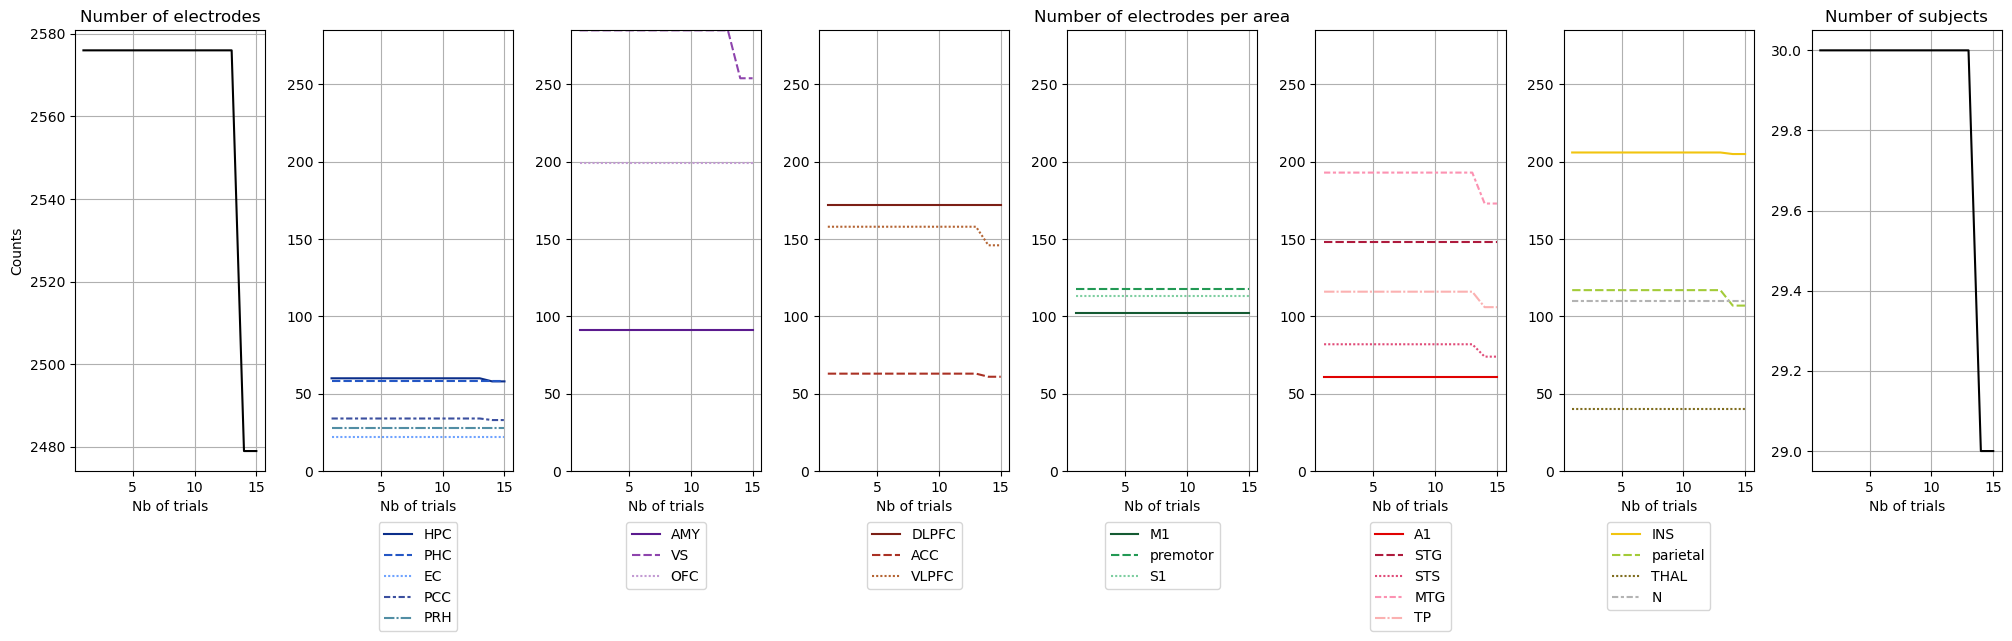

In [7]:
from src.config import COL_REG
import seaborn as sns

fig, ax = plt.subplots(1, 2+len(list_reg), figsize=(20, 5))
fig.tight_layout()
ax[0].plot(restriction.index, restriction['el_nb'], c='k')
ax[1+len(list_reg)].plot(restriction.index, restriction['subj_nb'], c='k')

for l, list_ in enumerate(list_reg) :
    sns.lineplot(restriction.loc[:, list_], palette = COL_REG, ax=ax[1+l])
    ax[1+l].legend(bbox_to_anchor= (0.5, -0.1), loc='upper center')
    ax[1+l].set_ylim(0,np.max(restriction.loc[:, 'AMY':]))


for a in ax :
    a.grid()
    a.set_xlabel('Nb of trials')

ax[0].set_ylabel('Counts')
ax[0].set_title('Number of electrodes')
ax[1+len(list_reg)].set_title('Number of subjects')
ax[4].set_title('Number of electrodes per area')


In [8]:
# try PCA stability with only those subject 

from src.decomposition import ConcatPCA

# get the mean data 
sub_meta_data = meta_data[(meta_data['new'] >= 16) & (meta_data['old'] >= 16)]
data_grp = get_data_grp(sub_meta_data.subj.values, return_subj=False, data_path=tfr_path, polarity_cor=(False,0), type_data='tfr')
centered_all_concat= np.concatenate([data_grp[i, :,:,:] for i in [0, 1]], axis=2)

df_Componants, df_X_transformed, mean = ConcatPCA({'grp' : centered_all_concat}, ch_id = False, nb_compo=3, return_mean=True)

In [9]:
sub_meta_data.subj.values

array(['BJH072', 'LL36', 'BJH069', 'SLCH020', 'BJH045', 'LL14', 'BJH050',
       'BJH027', 'OS70', 'BJH052', 'OS61', 'BJH041', 'BJH046', 'BJH056',
       'LL31', 'BJH039', 'BJH042', 'BJH026', 'LL08', 'SLCH018', 'BJH029',
       'DA037', 'BJH058', 'SLCH024', 'BJH049'], dtype=object)

In [13]:
sub_meta_data.old.values

array([24, 19, 24, 18, 21, 19, 20, 24, 24, 20, 22, 24, 24, 23, 24, 24, 23,
       24, 20, 24, 24, 21, 24, 21, 24], dtype=object)

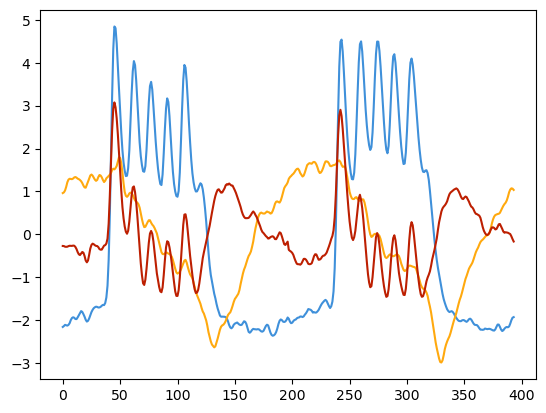

In [10]:
d= df_X_transformed.query('freq == "high_gamma"').drop(columns = ['compo', 'freq', 'subj', 'expl_var'])
plt.plot(d.T)